In [192]:
# Install required package (only needed if not already installed)
!pip install linearmodels

## Exploratory Data Analysis

In [194]:
# Importing relevant packages & loading dataset :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Previously used Colab upload; replaced with local file loading for submission
# from google.colab import files
# uploaded = files.upload()
# import io
# Get the actual filename from the uploaded dictionary
# filename = next(iter(uploaded))
# data = pd.read_csv(io.BytesIO(uploaded[filename]))

data = pd.read_csv("Urbanisation.csv")

In [195]:
# Visualizing the data to decide on the next steps
data.info()
data.describe()

# Visializing and counting the different countries available, confirming there are 28 enteries in each for 28 years of data
data['country'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     1008 non-null   object 
 1   co2.pc      1008 non-null   float64
 2   pop         1008 non-null   float64
 3   en.pc       1008 non-null   float64
 4   gdp.pc      1008 non-null   float64
 5   lagco2.pc   1008 non-null   float64
 6   co2.pc_gwt  1008 non-null   float64
 7   pop_gwt     1008 non-null   float64
 8   gdp.pc_gwt  1008 non-null   float64
 9   urb         1008 non-null   float64
 10  ci          1008 non-null   float64
 11  edu         1008 non-null   float64
 12  id          1008 non-null   float64
dtypes: float64(12), object(1)
memory usage: 102.5+ KB


country
Australia        28
Austria          28
Lithuania        28
Luxembourg       28
Mexico           28
Netherlands      28
New Zealand      28
Norway           28
Poland           28
Portugal         28
Slovakia         28
Slovenia         28
South Korea      28
Spain            28
Sweden           28
Switzerland      28
Turkey           28
Latvia           28
Japan            28
Italy            28
Estonia          28
Belgium          28
Canada           28
Chile            28
Colombia         28
Czechia          28
Denmark          28
Finland          28
Israel           28
France           28
Germany          28
Greece           28
Hungary          28
Iceland          28
Ireland          28
United States    28
Name: count, dtype: int64

In [196]:
# Making a list containing the names of the countries
countries =  set(data['country'])
countries = list(countries)
countries.sort()
len(countries) # to add a year column

36

In [197]:
# Adding a year column (for more plots & later train-val-test splits)
data['year'] = list(range(1975, 2003)) * len(countries)
data

,country,co2.pc,pop,en.pc,gdp.pc,lagco2.pc,co2.pc_gwt,pop_gwt,gdp.pc_gwt,urb,ci,edu,id,year
0,Australia,16.398,17.189235,61109.317,26819.332839,16.471,-0.004432,0.013480,-0.019961,85.403,31.096928,14.065310,1.0,1975
1,Australia,16.454,17.402179,60973.443,27458.816406,16.398,0.003415,0.012388,0.023844,85.285,32.553606,13.204020,1.0,1976
2,Australia,16.550,17.603211,61994.866,28451.660837,16.454,0.005834,0.011552,0.036158,85.157,34.252447,15.016920,1.0,1977
3,Australia,16.860,17.798526,63758.248,29628.643024,16.550,0.018731,0.011095,0.041368,85.028,34.648949,14.297020,1.0,1978
4,Australia,17.119,17.993083,64743.818,30521.332787,16.860,0.015362,0.010931,0.030129,84.898,32.600000,14.770060,1.0,1979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,United States,17.331,318.673422,81112.618,51722.739312,17.302,0.001676,0.007184,0.015934,81.483,41.500000,13.257856,36.0,1998
1004,United States,16.741,320.878312,79771.642,52675.977754,17.331,-0.034043,0.006919,0.018430,81.671,41.200000,13.545640,36.0,1999
1005,United States,16.247,323.015992,79130.818,53132.221473,16.741,-0.029508,0.006662,0.008661,81.862,41.100000,13.154210,36.0,2000
1006,United States,16.020,325.084758,78894.410,54128.294844,16.247,-0.013972,0.006405,0.018747,82.058,41.200000,13.864670,36.0,2001


From the initial analysis done above, we conclude that none of the entries are missing. All the columns are float except country and none of the countries have typos. There are 28 entries per country each corresponding to a year from 1975 to 2002, which we added a column for.

**Visualizing Plots**


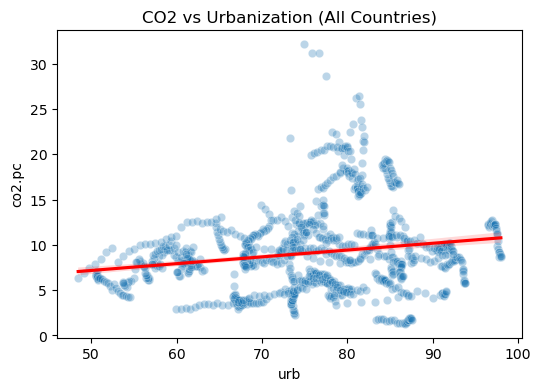

In [200]:
# We graph the target against the main regressor to visualize any possible trend across all the countries.
plt.figure(figsize=(6,4))
sns.scatterplot(data=data, x='urb', y='co2.pc', alpha=0.3)
sns.regplot(data=data, x='urb', y='co2.pc', scatter=False, color='red')
plt.title('CO2 vs Urbanization (All Countries)')
plt.show()

Plot shows that a trend does exist and a linear model might be a good start. From there we go deeper into each country separetely.

<Axes: >

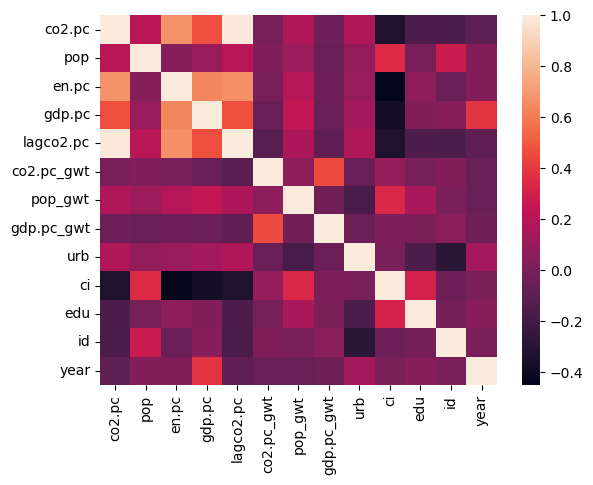

In [202]:
# Heatmap to visaulize the correlation between variables
numer_data = data.select_dtypes(include='number')
all_corr = numer_data.corr()
all_corr
sns.heatmap(all_corr)

Based on the heatmap, CO₂ emissions are positively correlated to energy consumption and GDP, while the relationship with urbanization appears weak.This could imply that urbanisation is affected by other factors that are specific to each country.

Performing data analysis on the entire dataset (like the heatmap) fails to account for each country's other factors/effects and masks the underlying trends.

In [204]:
corrs= data.groupby('country')[['co2.pc','urb']].corr().iloc[::2,-1]
corrs

country              
Australia      co2.pc   -0.732263
Austria        co2.pc   -0.047152
Belgium        co2.pc   -0.853914
Canada         co2.pc   -0.179087
Chile          co2.pc   -0.116412
Colombia       co2.pc   -0.090211
Czechia        co2.pc   -0.919206
Denmark        co2.pc    0.724675
Estonia        co2.pc   -0.186110
Finland        co2.pc   -0.741579
France         co2.pc   -0.955497
Germany        co2.pc    0.862062
Greece         co2.pc   -0.296944
Hungary        co2.pc   -0.862827
Iceland        co2.pc    0.682910
Ireland        co2.pc   -0.815591
Israel         co2.pc   -0.509264
Italy          co2.pc   -0.489149
Japan          co2.pc   -0.046401
Latvia         co2.pc   -0.208857
Lithuania      co2.pc   -0.101106
Luxembourg     co2.pc   -0.655785
Mexico         co2.pc   -0.869685
Netherlands    co2.pc   -0.897236
New Zealand    co2.pc   -0.431539
Norway         co2.pc   -0.008973
Poland         co2.pc   -0.605600
Portugal       co2.pc   -0.170175
Slovakia       co2.pc   -0

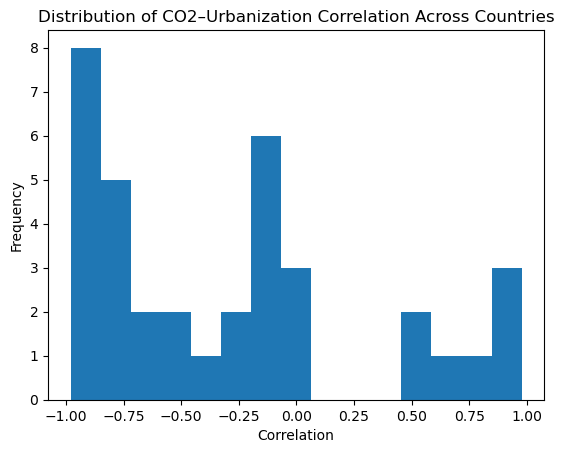

In [205]:
plt.hist(corrs, bins=15)
plt.title('Distribution of CO2–Urbanization Correlation Across Countries')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.show()

In most countries, the CO2 emissions per capita shows strong correlation with urbanisation, and in many of them, it's a negative relationship where CO2 emissions decrease as urbanisation increases.

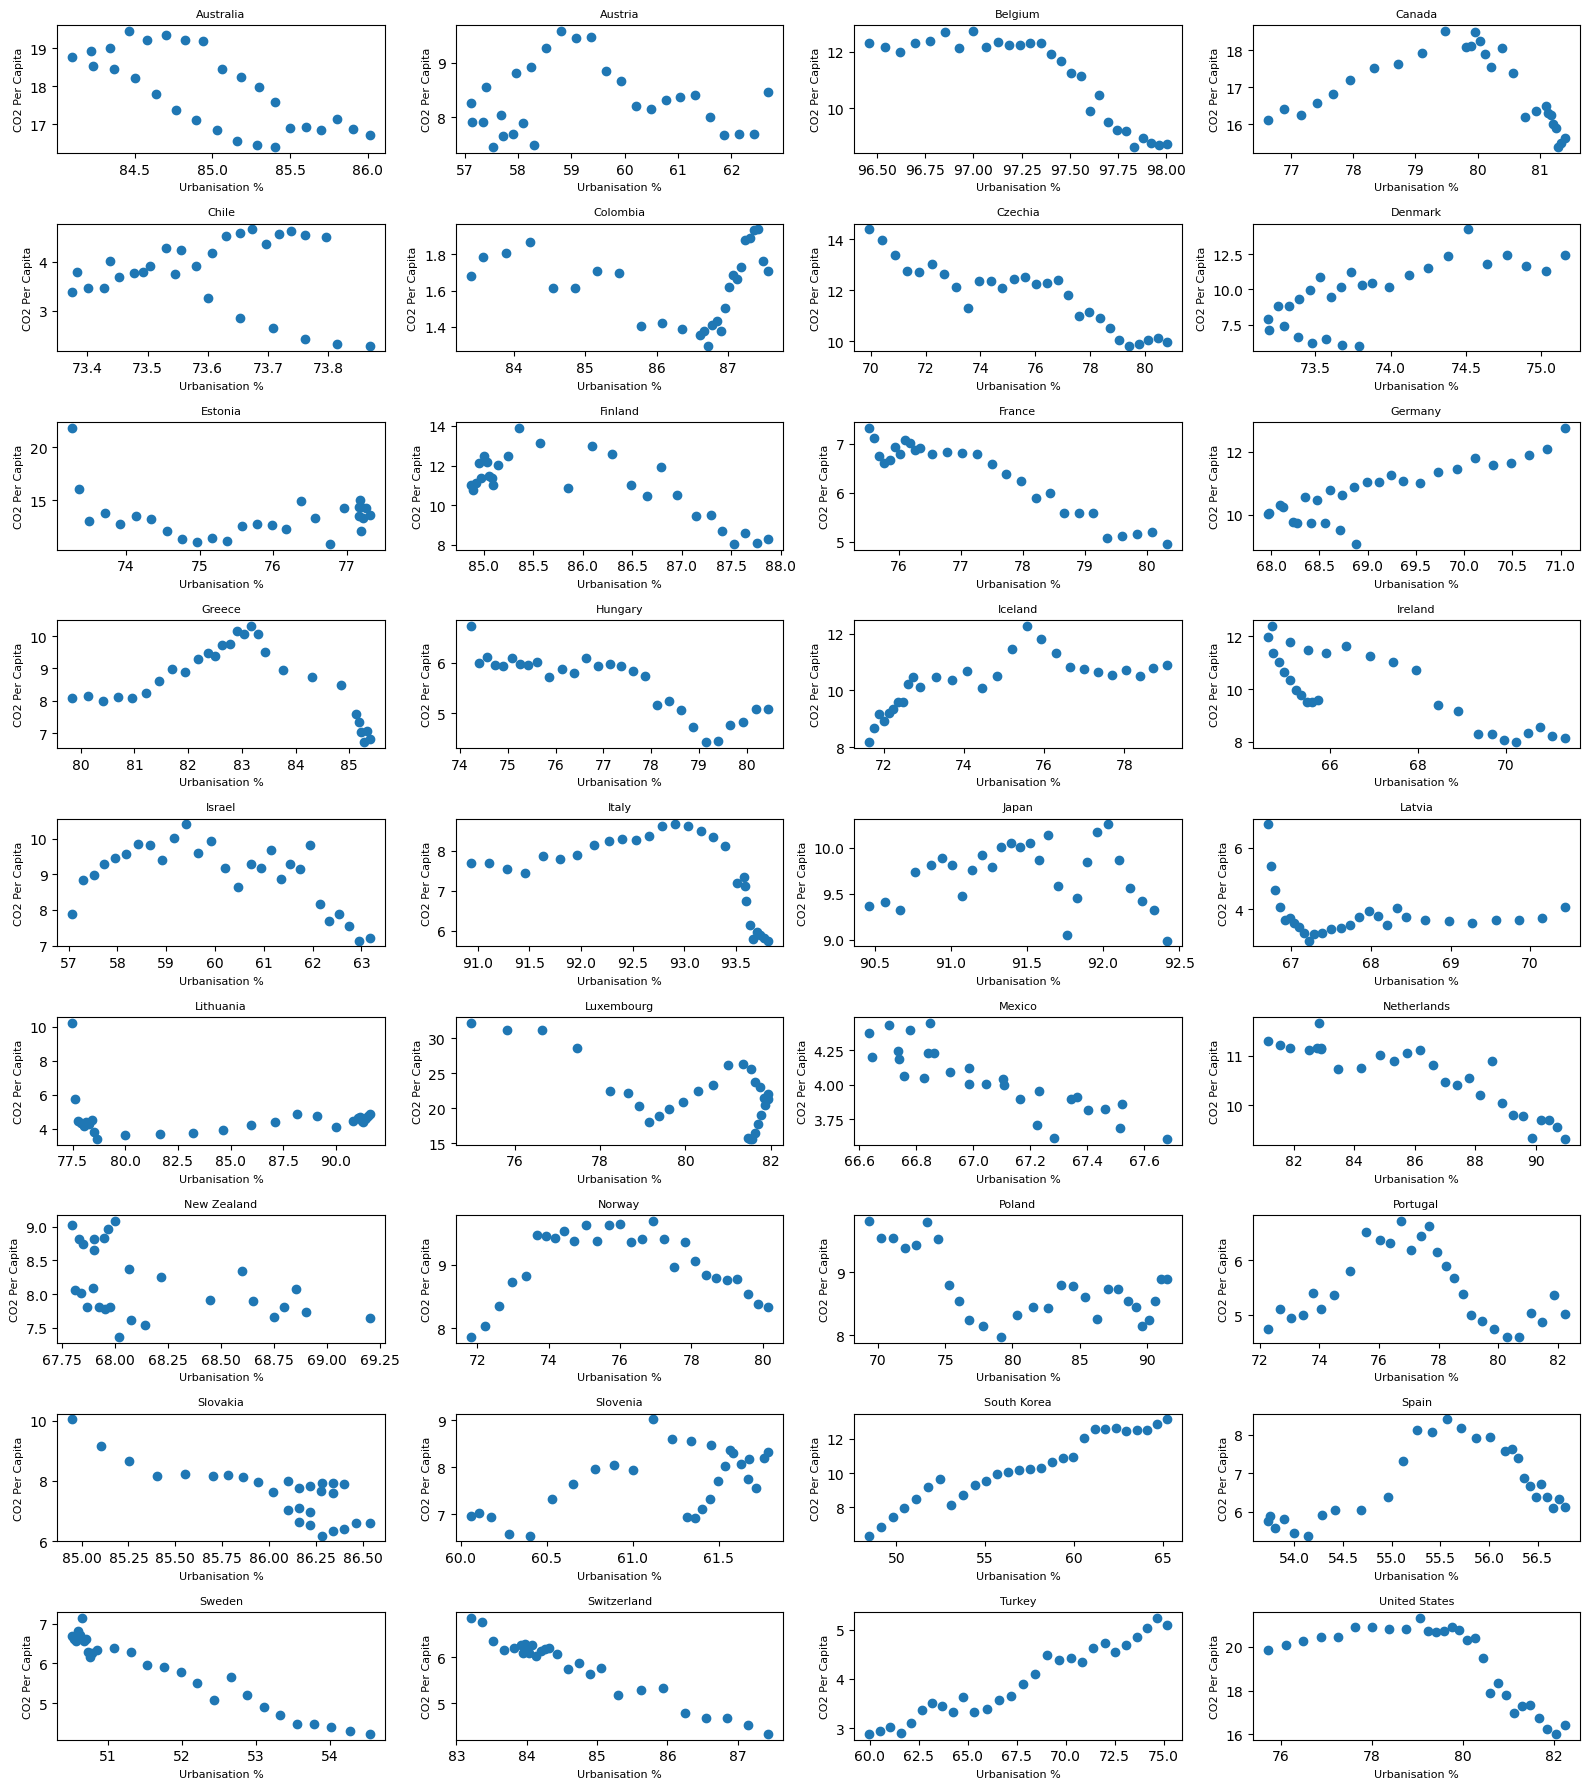

In [207]:
# We graph the target against the main regressor to visualize any possible trend for each country.
plt.figure(figsize=(16, 18))
for i, country in enumerate(countries):
    plt.subplot(9, 4, i+1)
    x = data.loc[data['country']==country,'urb']
    y = data.loc[data['country']==country,'co2.pc']
    plt.scatter(x,y)
    plt.title(country, fontsize=8)
    plt.xlabel('Urbanisation %', fontsize=8)
    plt.ylabel('CO2 Per Capita',fontsize=8)

plt.tight_layout()
plt.show()

Splitting the graphs down to the countries allowed us to see specific trends, we were able to see patterns that were hidden in the pooled scatter plot. We can see there are almost linear relationships in many of the countries; some are positive and some are negative. As well as some quadratic relationships.

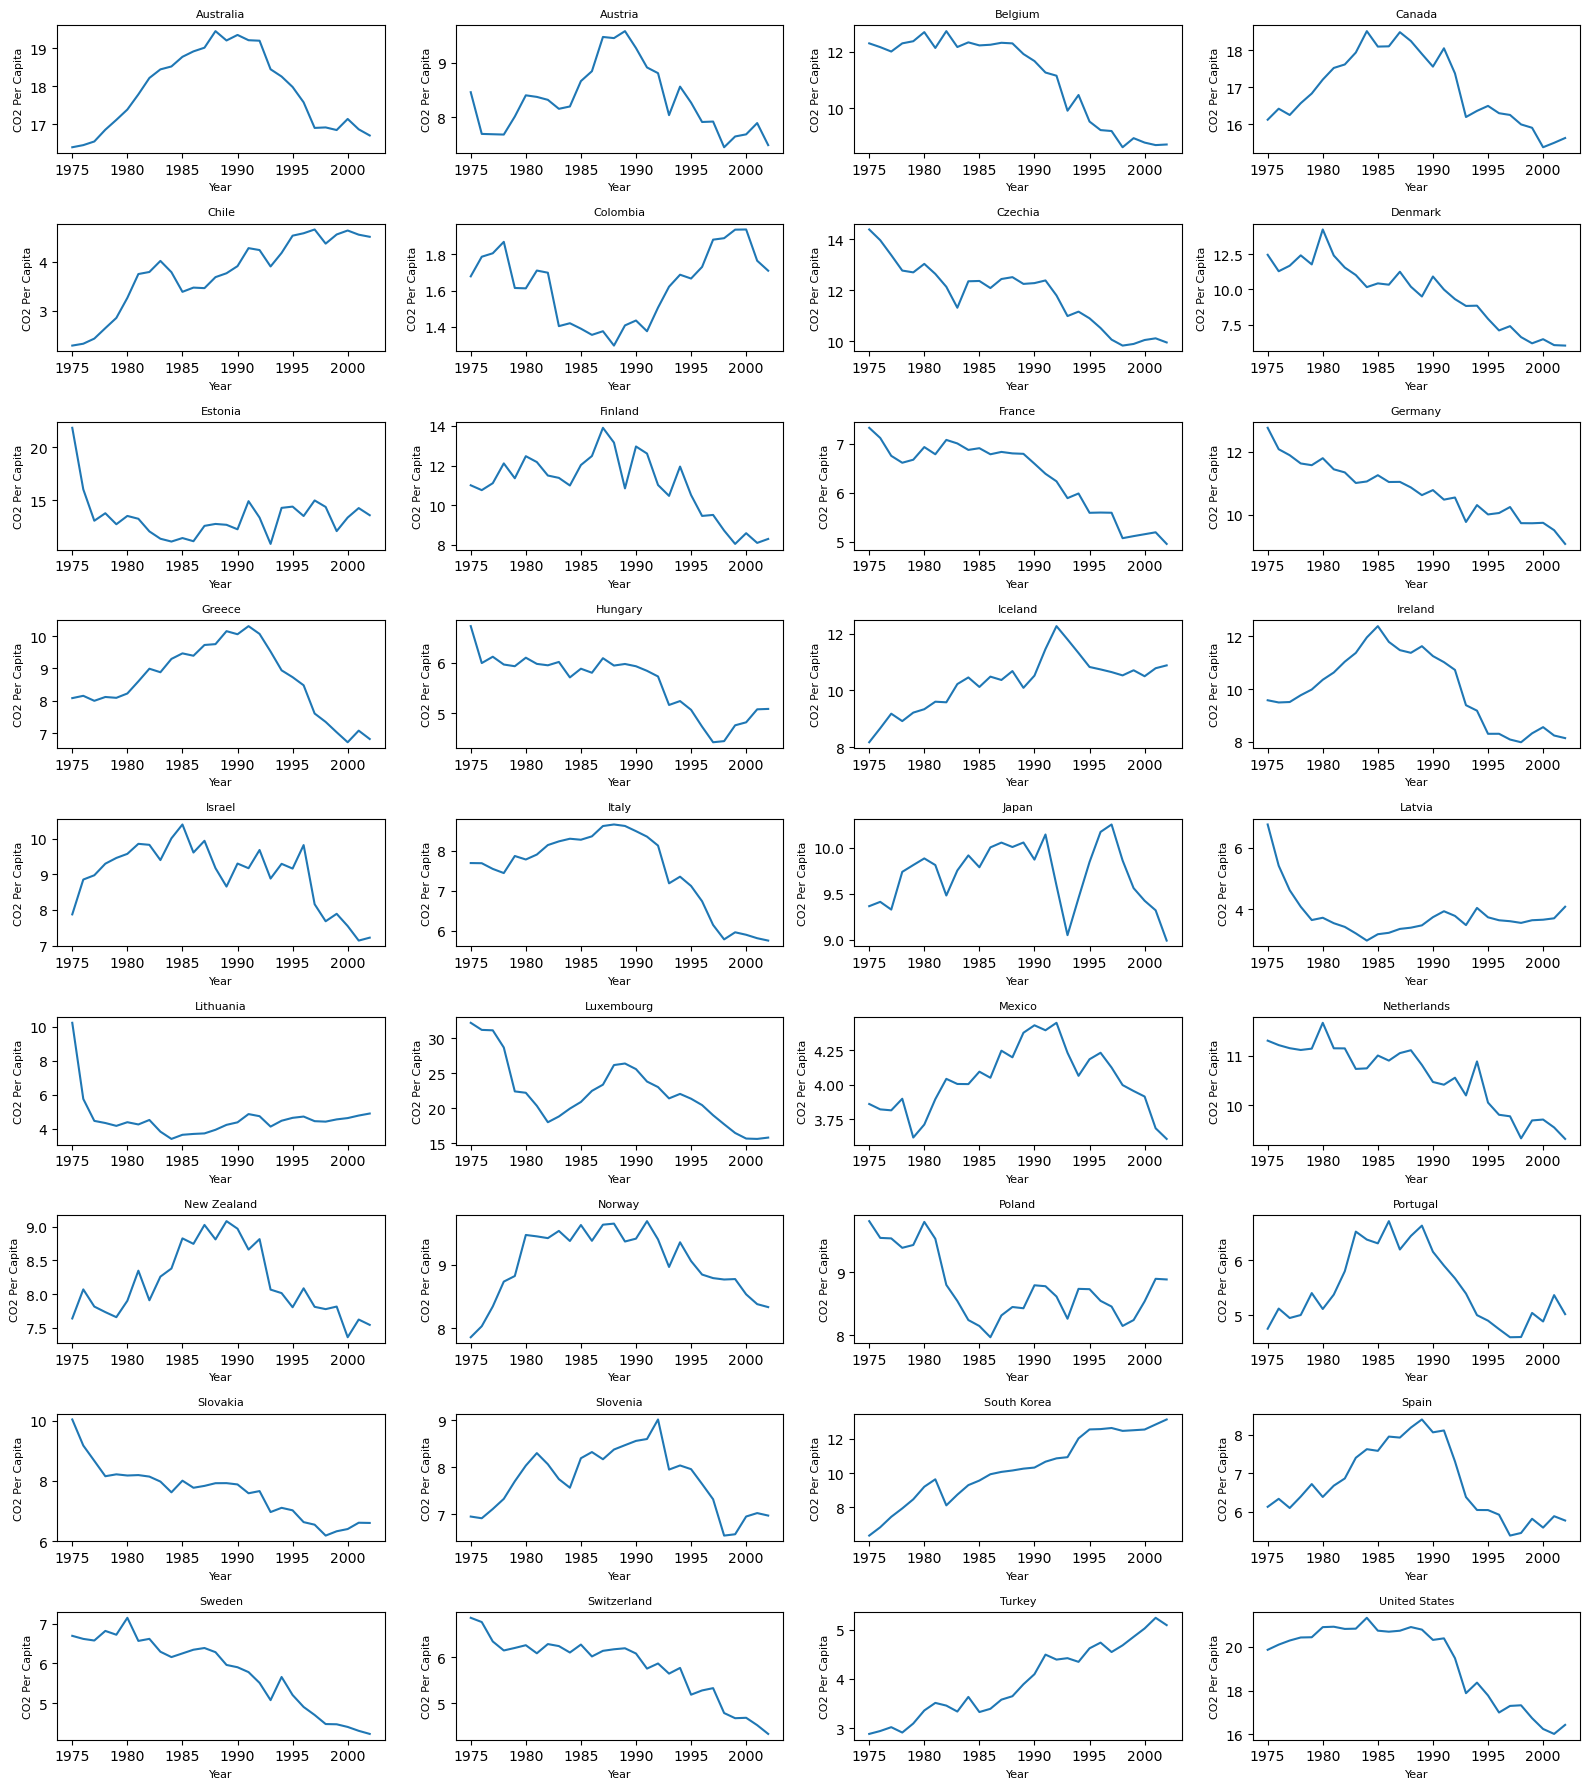

In [209]:
#We visualize co2 against time
plt.figure(figsize=(16, 18))
for i, country in enumerate(countries):
    plt.subplot(9, 4, i+1)
    subset = data[data['country'] == country].copy()
    years_per_country = subset['year']
    plt.plot(subset['year'], subset['co2.pc'])
    plt.title(country, fontsize=8)
    plt.xlabel('Year', fontsize=8)
    plt.ylabel('CO2 Per Capita',fontsize=8)

plt.tight_layout()
plt.show()

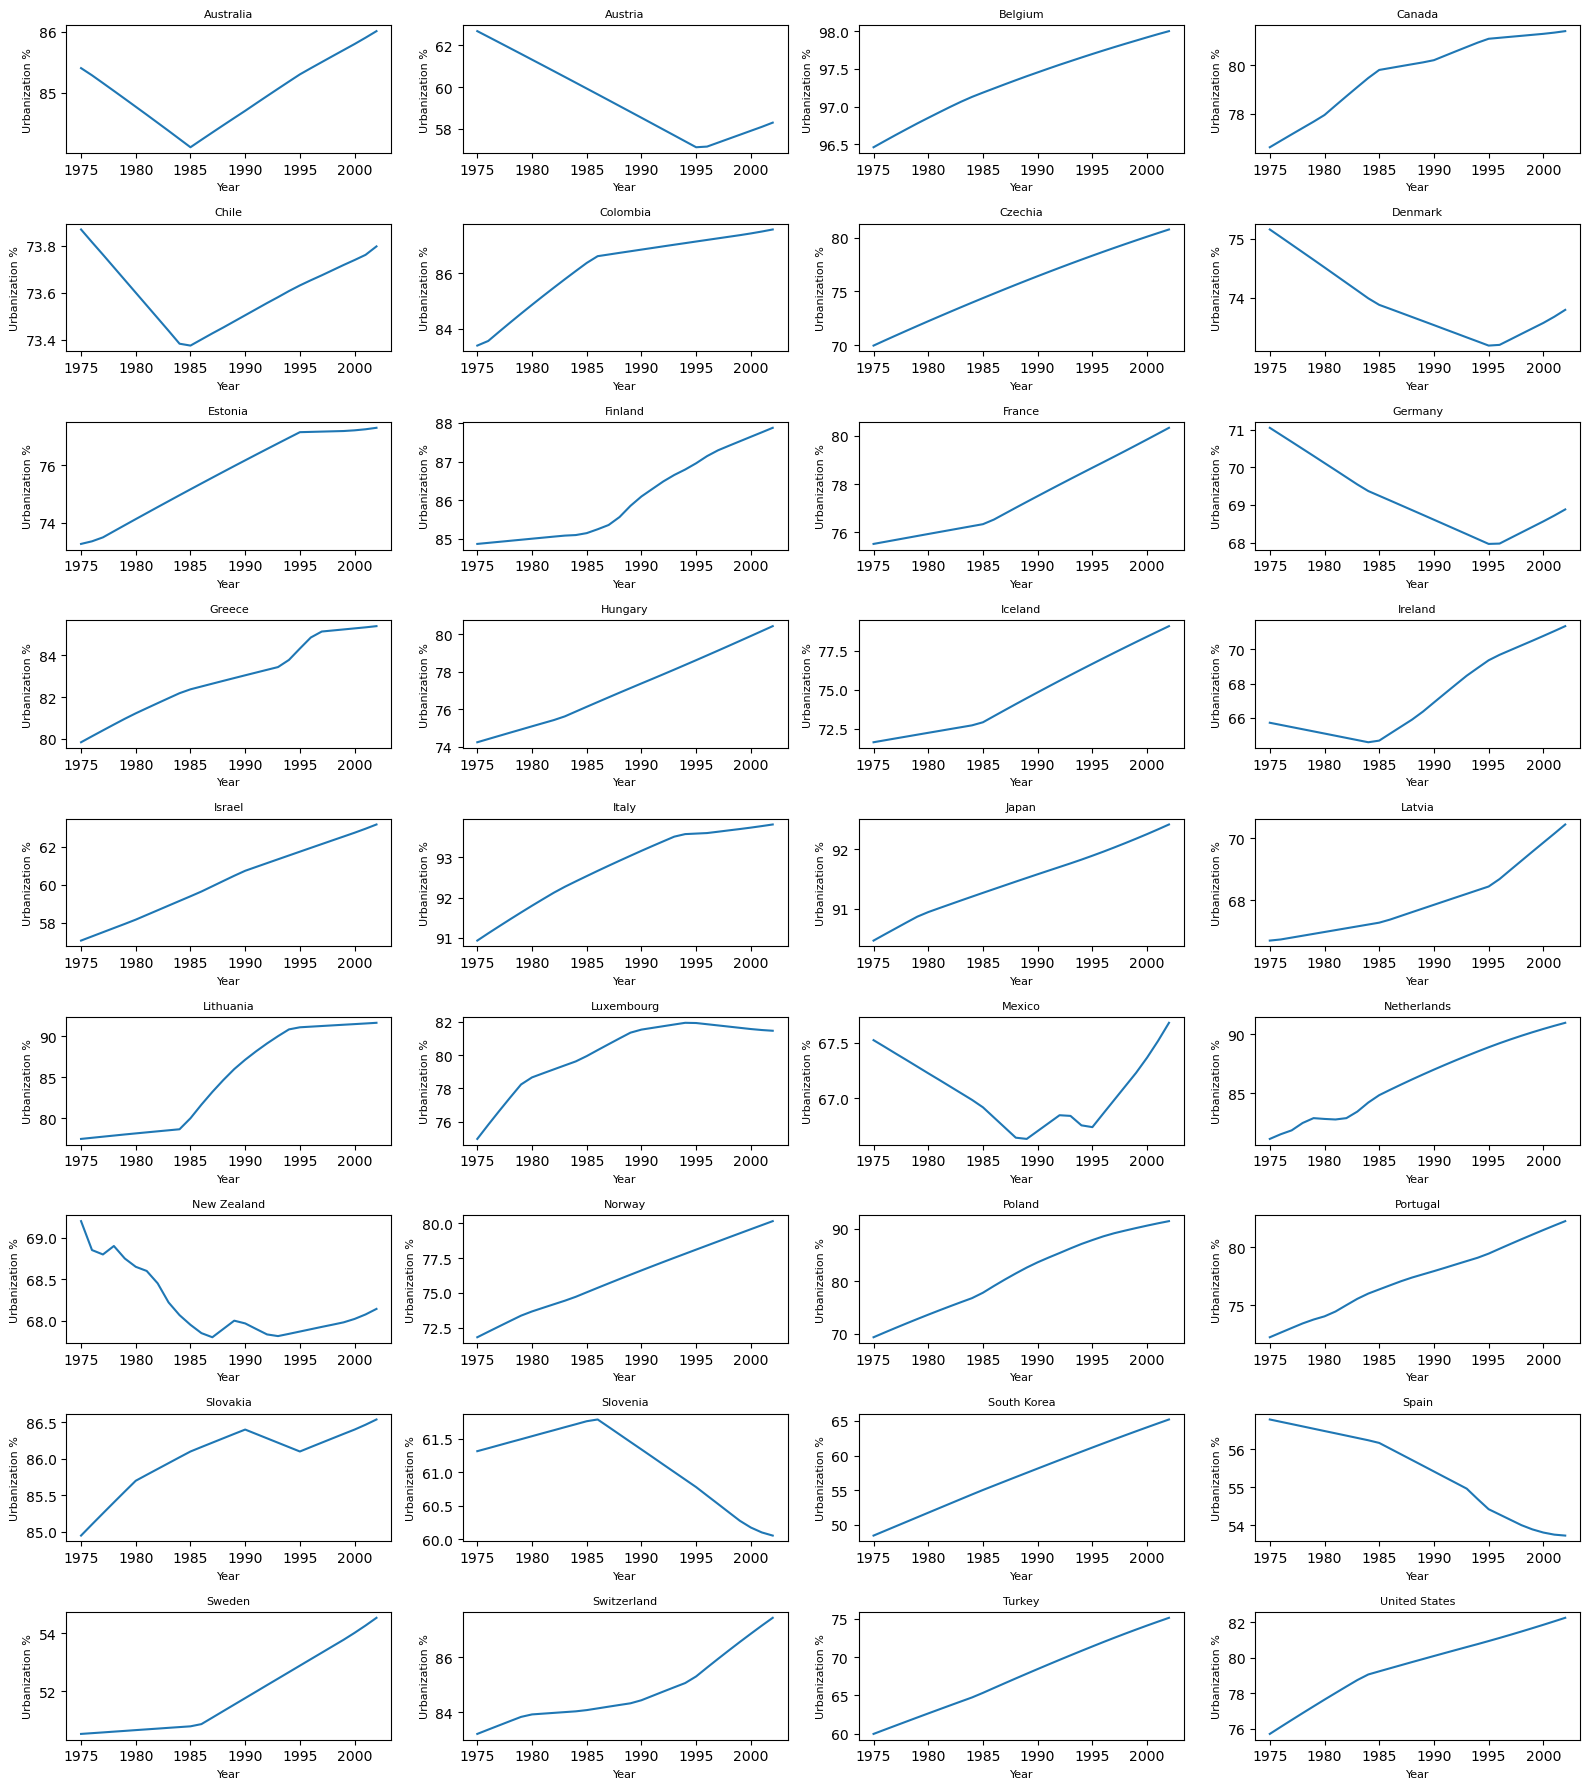

In [210]:
# We visualize urb against time
plt.figure(figsize=(16, 18))
for i, country in enumerate(countries):
    plt.subplot(9, 4, i+1)
    subset = data[data['country'] == country].copy()
    years_per_country = subset['year']

    # Plot CO2 per capita against the newly created 'year' column.
    plt.plot(subset['year'], subset['urb'])
    plt.title(country, fontsize=8)
    plt.xlabel('Year', fontsize=8)
    plt.ylabel('Urbanization %',fontsize=8)

plt.tight_layout()
plt.show()

These graphs show how the CO2 and Urbanization % change over time for each country. The plots show that CO2 emissions and Urbanization % changes differently across countries, some increasing or decreasing constantly, while several others show nonlinear patterns. The consistency of such clear relationships in each case shows that these variables are important features in the dataset.

Countries like Belgium, Czechia, Estonia, France, Latvia, Netherlands, Slovakia, Sweden, Switzerland, and United States had their CO2 emissions decrease as their Urbanization % increased. Countries like Denmark and Germany had their CO2 emissions increase as Urbanization % decreased, whereas countries like South Korea and Turkey had CO2 and Urbanization % increase together.

It is also good to note that for some countries, emissions and Urbanization % start off high, then (between 1990-1995) had their emissions decrease while their Urbanization % continues to increase. A possible explanation for this could be the technological advancements in the world that improved living conditions. These countries include Canada, Greece, Iceleand, Isreal, Italy, Japan, Norway, and Portugal. Luxembourg and Lithuania see this advancement ealier; between 1980 and 1985.



Overall, most of the countries show an increase in urbanization across the years. As well as almost linear and quadratic trends in CO2 emissions.

# Split + Initial Model — Linear Pooled OLS



In [214]:
# Making country and year the indexes (since the function PooledOLS we use below requires 2-level index in the form (entity, time) as its built for panel data)
data = data.set_index(["country", "year"])

In [215]:
# This is roughly a 60-20-20 split
train = data[data.index.get_level_values("year") <= 1990] # can't directly use year as it's an index
val   = data[(data.index.get_level_values("year") >= 1991) & (data.index.get_level_values("year") <= 1996)]
test  = data[data.index.get_level_values("year") >= 1997]

variables = ['urb', 'gdp.pc','en.pc'] # extracting the correlated variables


X_train = train[variables]
X_val = val[variables]                # splitting the predictors
X_test = test[variables]

y_train = train["co2.pc"]
y_val = val["co2.pc"]                 # splitting the response (CO2 emissions per capita)
y_test = test["co2.pc"]

The dataset is split into training, validation, and test set based on time rather than a random sampling, this is done so that we can keep the time structure of the panel data while avoiding future data leaking into the model (so the model will be forecasting for future unseen years). The data is split by a 60-20-20 ratio.

In [217]:
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from linearmodels.panel import PooledOLS # using this instead of statsmodels.OLS because this one is built for panel data, more appropriate + helpful later for less FE setup work!

In [218]:
X_train_const = sm.add_constant(X_train)    # here we are adding a constant term to the regressors
model_1 = PooledOLS(y_train, X_train_const)
results_1 = model_1.fit()                   # this line estimates the linear pooled OLS model on the training data
print(results_1.summary)                    # we print the summary of the model

                          PooledOLS Estimation Summary                          
Dep. Variable:                 co2.pc   R-squared:                        0.5305
Estimator:                  PooledOLS   R-squared (Between):              0.5398
No. Observations:                 576   R-squared (Within):               0.3477
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.5305
Time:                        12:06:26   Log-likelihood                   -1515.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      215.43
Entities:                          36   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(3,572)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):             215.43
                            

Urbanisation %, CO2 emissions per capita, and energy per capita are statistically significant predictors as their p-values are small (< 0.05). While the coeffecients may seem absurdly small at first, they make sense and are meaningful once the large units of these quantities are considered (%, metric tons, and likely kWh).

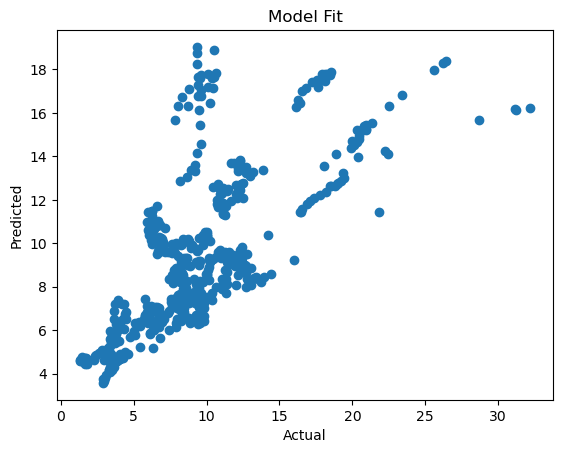

In [220]:
y_train_pred = results_1.predict(X_train_const) # using the model to predict the CO2 emissions using the linear model

# This plot will compare the actual training set CO2 emissions with the values we predicted using the linear pooled OLD model.
plt.scatter(y_train, y_train_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Fit")
plt.show()

The model does well on the training data if the points cluster arounds the diagonal line y=x. The closer they are, the closer the predictions are to their actual value.

The plot shows that the predictions are somewhat clustering around the diagonal line with a few of them being far from the actual value. We can check the overall error of this model with the mean squared error (MSE) and the mean absolute error (MAE) using the validation set to evaluate the model.

In [222]:
# Now use validation set to evaluate model (compare to others val metrics later, test only to be used on final chosen model!)

X_val_const = sm.add_constant(X_val)                                 # adding a constant term to the regressors
y_pred_val_lin = results_1.predict(X_val_const)                      # use the model to predict on the validation set

from sklearn.metrics import mean_squared_error, mean_absolute_error  # importing appropriate performance metrics functions

mse_val_lin = mean_squared_error(y_val, y_pred_val_lin)              # calculating MSE
rmse_val_lin = mse_val_lin ** 0.5                                    # calculating RMSE

mae_val_lin = mean_absolute_error(y_val, y_pred_val_lin)             # calculating MAE

mse_val_lin, rmse_val_lin, mae_val_lin                               # we'll use this to compare it with quadratic pooled OLS (and other models)

(12.553302453433968, 3.5430639922860507, 2.5197416929239345)

The MSE, RMSE, and MAE are relatively low for the model meaning the predictions are were made accurately for a great portion of the validation set (which was not seen by the model before). These validation metrics will later on be compared to the quadratic model to see if using a nonlinear model will improve the performence.

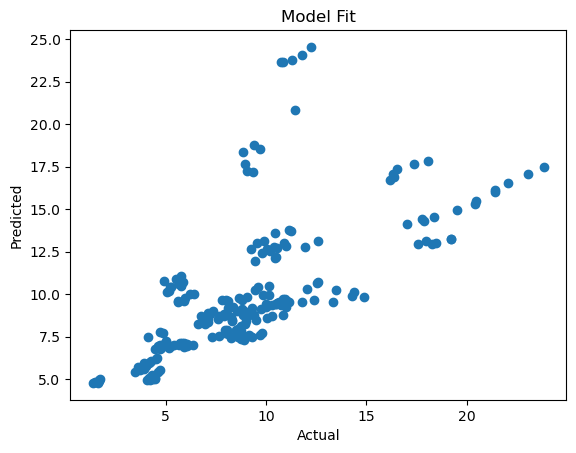

In [224]:
# This plot will compare the actual validation set CO2 emissions with the linear predicted validation values

plt.scatter(y_val, y_pred_val_lin)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Fit")
plt.show()

This plot compares actual CO2 emissions with the predicted values on the validation set. This graph is more informative bacause it evaluates the prediction model based on the predictions it made on the unseen validation set.

The validation's plot seems to be further away from the y=x line, but this makes sense because it is expected to be worse than the training set due to the fact that the data is unseen by the model. However, the points still follow the upwards trend. Overall, the model did a good job predicting if we take into account the fact that it is unseen data, even if the slope is a bit lower than y=x.

**Basic Diagnostics: Multicollinearity Check, Residual Plots**

We've seen that the variables urb, gdp.pc, and en.pc are correlated variables with CO2 emissions, so to make sure there are no other relationship between the variable we will check their multicollinearity.

In [228]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


Xvars = X_train[["urb", "gdp.pc", "en.pc"]]  # Extracting the correlated variables

Xvars = sm.add_constant(Xvars)   # A constant is added to represent the y-intercept  (When we decide the constant needs to be here)

vif_values = []

# Calculating
for i in range(Xvars.shape[1]):
    vif = variance_inflation_factor(Xvars.values, i)
    vif_values.append(vif)

# making is a dataframe for better presentaation
vif_data = pd.DataFrame()
vif_data["Variable"] = Xvars.columns
vif_data["VIF"] = vif_values

print(vif_data)

  Variable        VIF
0    const  49.000047
1      urb   1.027261
2   gdp.pc   2.277158
3    en.pc   2.269172


The Variance Inflation Factor (VIF) is a metric used to measure how much the variance of the estimated coefficients in a multi regression model is increased because of collinearity. From the table above we can see that the variables all have a VIF value less than 5, which means they don't suffer from multicollinearity. This shows that our variable choices would not effect the model in a bad way.

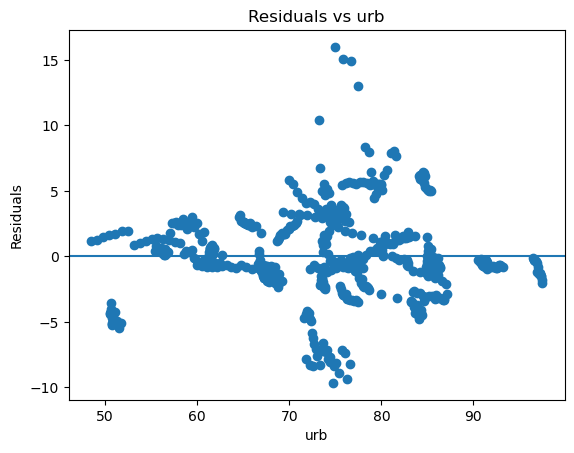

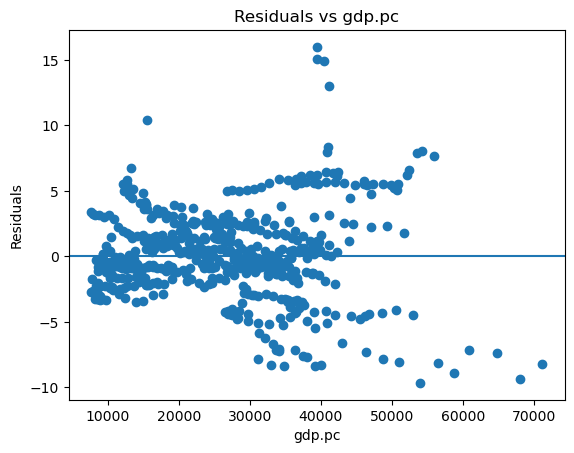

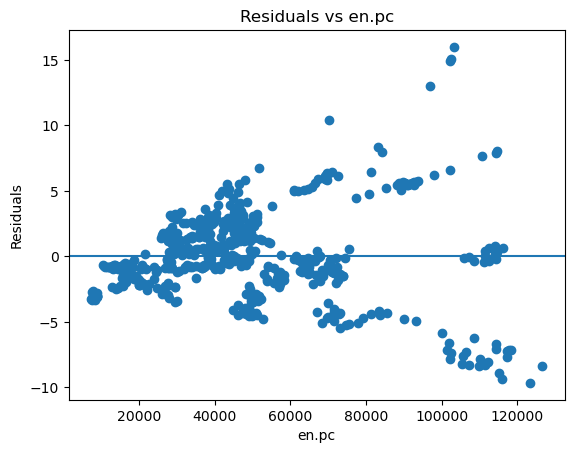

In [230]:
residuals = y_train - y_train_pred['predictions'] # Finding the residuals for the model predictions

for var in variables:   # Starting a for loop to create residual plots for each variable
    plt.scatter(X_train[var], residuals)
    plt.axhline(0)
    plt.xlabel(var)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs {var}")
    plt.show()

The residual plots against every variable shows how good the model interprets the relationship between the residuals and the prdeictors (the variables). If the model predicts good then we expect the residuals to be randomly scattered around the zero, meaning we didnt miss any identification of other relationships. A line at zero was added for clear evaluation of residuals.

For urb, most of the residuals are scattered near zero, and there is a sudden increase of distance of the residuals from the zero line around 70-80 urbanization.

For gdp.pc, at lower values there is a tight cluster around zero and at higher values there is a much wider spread of residuals, especially towards the negative side.

For en.pc, the spread of residuals kind of looks like a cone shape. At lower values of energy its clustered near zero but then at higher value of energy the residuals increase in both directions, they disperse or increase in spread.

The plots show that the spread of residuals is not constant across all values of the variables and all have some type of cone pattern. This pattern is consistent with heteroskedasticity, which is common in panel data. The increasing spread of residuals across the variables shown in the plot is consistent with heteroskedasticity, which suggests that the variance of the errors is not constant like OLS assumes. This leads to unreliable standard errors and hypothesis tests. With an incorrect standard error, we could conclude that a variable is significant when it actually isn't.



# Quadratic Pooled OLS

In this section we are going to experiment with a quadratic model to allow the effect of urbanization to be non-linear. A square Urbanization term is added to test the relationship between Urbanization and CO2 emission. The relationship may follow a curved pattern, either U-shaped or inverted U-shaped.

Text(0.5, 1.0, 'Testing for Nonlinear Relationship')

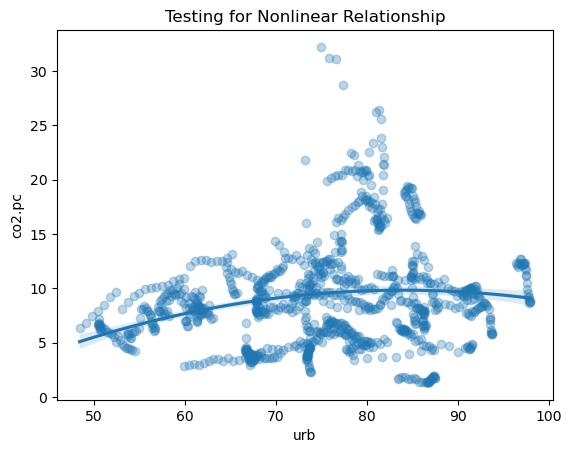

In [235]:
# Here we are adding a second-order polynomial fit to check for non-linearaity for the relationship between Urbanization and CO2 emissions. We are essentially checking visually if the relationship is better curved rather that a straight line
sns.regplot(data=data, x='urb', y='co2.pc',
            order=2, scatter_kws={'alpha':0.3})
plt.title('Testing for Nonlinear Relationship')

We are essentially checking visually if there is a relationship that is curved, and if it is better than a straight line. The fitted curve bends slightly, this means that the relationship may not be purely linear. For this reason, we will include a squared Urbanization term in our second model.

Even if the graph doesn't visually show high non-linearity, the final conclusion about non-linearity should be made with the regression coffecients rather than just the plot alone.

From the previously split data we carry on defining the next model.

In [238]:
train_q = train.copy()
val_q = val.copy()     # copying new splits for the quadratic model
test_q = test.copy()

In [239]:
train_q["urb_sq"] = train_q["urb"] ** 2
val_q['urb_sq'] = val_q['urb']**2                 # creating squared Urbanization variable
test_q['urb_sq'] = test_q['urb']**2

quad_vars = ['urb', 'urb_sq', 'gdp.pc', 'en.pc']  # extracted the previous variables + the new squared Urbanization variable

X_train_q = train_q[quad_vars]
X_val_q = val_q[quad_vars]                        # splitting the variables for training, validation, and testing
X_test_q = test_q[quad_vars]

X_train_const_q = sm.add_constant(X_train_q)      # adding a constant term to the regressors
model_2 = PooledOLS(y_train, X_train_const_q)
results_2 = model_2.fit()                         # estimating the quadratic pooled OLS model on the training data

print(results_2.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:                 co2.pc   R-squared:                        0.5376
Estimator:                  PooledOLS   R-squared (Between):              0.5476
No. Observations:                 576   R-squared (Within):               0.3410
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.5376
Time:                        12:06:30   Log-likelihood                   -1510.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      165.99
Entities:                          36   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(4,571)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):             165.99
                            

Once again, Urbanisation, squared Urbanisation, and energy per capita are all statistically significant predictors according to their p-values (< 0.05). Compared to the linear model, GDP per capita is now more statistically significant.

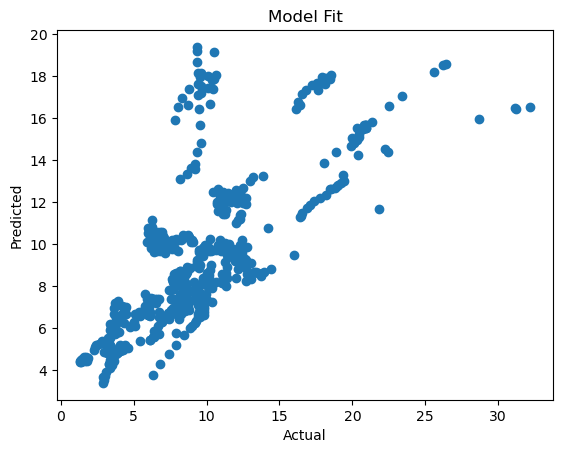

In [241]:
y_train_pred_q = results_2.predict(X_train_const_q)   # using the model to predict the CO2 emissions using the quadratic model

# This plot will compare the actual training set CO2 emissions with the values we predicted using the quadratic pooled OLS model.
plt.scatter(y_train, y_train_pred_q)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Fit")
plt.show()

The points of this plot appear more on the y=x line and the slope seems to be better than the linear model's, this means that the training data fits better on the quadratic model. However, this improvement alone is not enough to conclude anything, we need to check this model with the validation set to evaluate its generalization capabilities, moreover, the need to assess whether this extra complexity is actually useful using the metrics MSE, RMSE, and MAE.

In [243]:
X_val_const_q = sm.add_constant(X_val_q)         # adding a constant term to the regressors

y_pred_val_q = results_2.predict(X_val_const_q)  # using the model on the validation set


In [244]:
mse_val_quad = mean_squared_error(y_val, y_pred_val_q)  # calculating MSE
rmse_val_quad = mse_val_quad ** 0.5                     # calculating RMSE

mae_val_quad = mean_absolute_error(y_val, y_pred_val_q) # calculating MAE

mse_val_quad, rmse_val_quad, mae_val_quad # we'll use this to compare it with linear pooled OLS (and other models)

(12.402655722743061, 3.5217404394337555, 2.4546943799345633)

The quadratic model has a lower validation MSE, RMSE, and MAE than the linear model, but it's quite a small difference. This shows that although the quadratic model works effectively and had better metrics, it being not far off from the linear model (which was far less complex and more interpretable) means increasing the degree was likely not the right choice in improving our models to capture the cross-country trends. This serves as motivation for exploring different methods (like fixed effects) in later models.

We will check for multicollinearity here too.

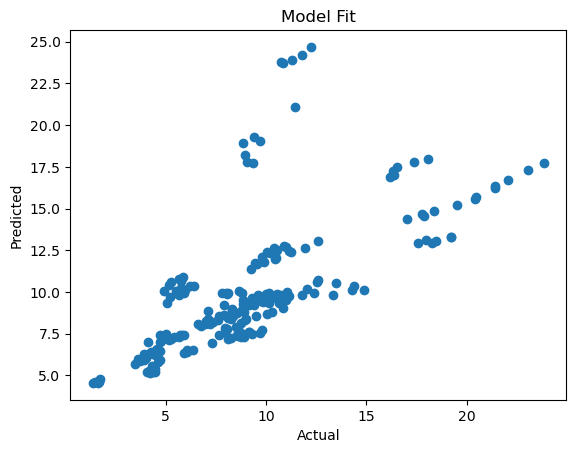

In [247]:
# This plot will compare the actual validation set CO2 emissions with the quadratic predicted validation values
plt.scatter(y_val, y_pred_val_q)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Fit")
plt.show()

Again, the validation's plot seems to be further away from the y=x line, but this makes sense because it is expected to be worse than the training set due to the fact that the data is unseen by the model. However, the points still follow the upwards trend. The plot looks very similar to the linear case, this suggests that there could be no gain from adding the squared term and making the model quadratic.

In [249]:
Xquad_vars = train_q[quad_vars].copy()

Xquad_vars = sm.add_constant(Xquad_vars)

quad_vif_values = []

# Calculating VIF for each variable
for i in range(Xquad_vars.shape[1]):
    quad_vif = variance_inflation_factor(Xquad_vars.values, i)
    quad_vif_values.append(quad_vif)

# making it a dataframe for better presentation
quad_vif_data = pd.DataFrame()
quad_vif_data["Variable"] = Xquad_vars.columns
quad_vif_data["VIF"] = quad_vif_values

print(quad_vif_data)

  Variable          VIF
0    const  1337.128433
1      urb   119.256663
2   urb_sq   119.486742
3   gdp.pc     2.323202
4    en.pc     2.293673


The VIF factors for gdp.pc and en.pc are similar to the linear model's, however the urb and its squared variable have an extremely high VIF. This is expected because a variable and its square are, by design, trivially going to be highly correlated. There isn't an obvious multicollinearity between the variables and they would not effect the quadratic model's performence badly.

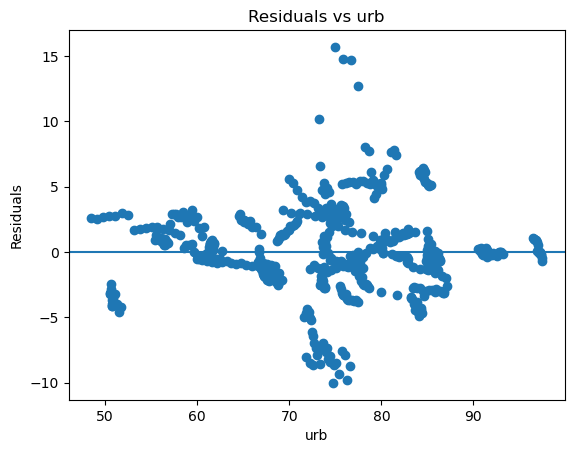

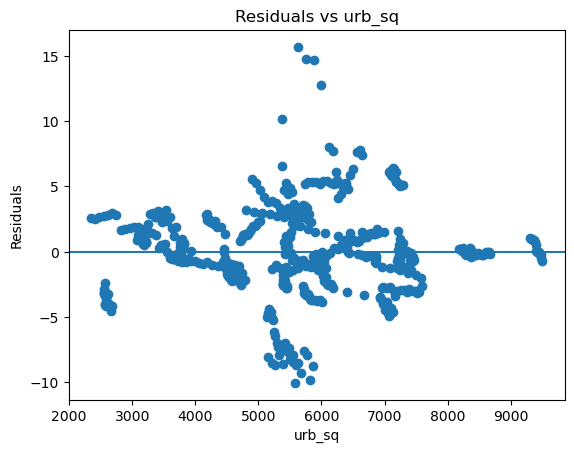

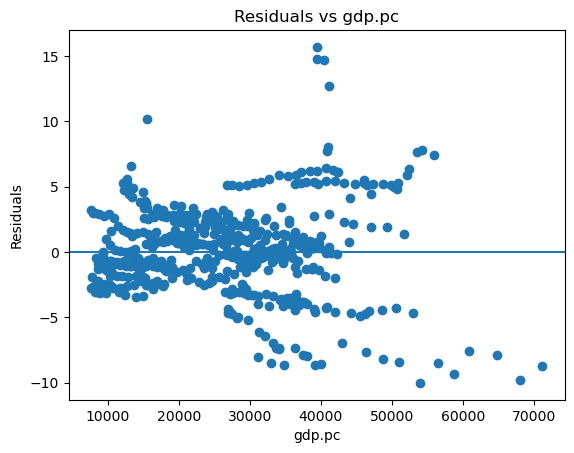

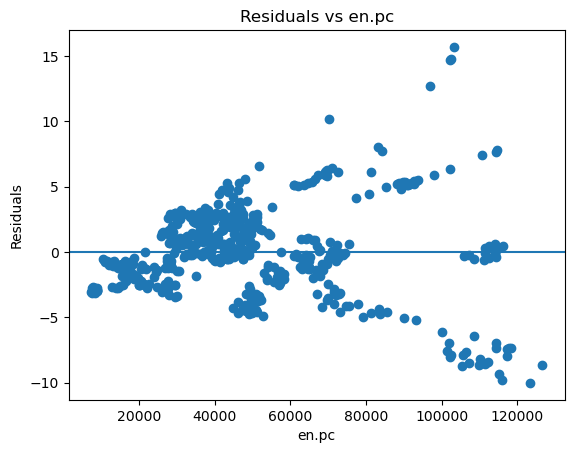

In [251]:
quad_residuals = y_train - y_train_pred_q['predictions'] # Finding the residuals for the model predictions

for var in quad_vars:   # Starting a for loop to create residual plots for each variable
    plt.scatter(X_train_q[var], quad_residuals)
    plt.axhline(0)
    plt.xlabel(var)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs {var}")
    plt.show()

The residual plot for the quadratic model is very similar to the linear model's. Although the added quadratic term urb_sq variable captures the curvature, it does not fix the residuals variance issue. In fact, the residual plot for urb_sq looks almost exactly like urb's. The quadratic model helps with modelling potential nonlinearity in the relationship, but still doesn't deal with heteroskedasticity due to the nature of OLS models mentioned previously.   

**Turning Point**

Here we will compute the turning point of the quadratic relationship using the fomula -b1 / (2 * b2), where b1 is the coefficient for the urb variable and b2 is the coefficient for the urb_sq variable. The turning point shows us at which level of Urbanization does the effect on CO2 switch direction. We will also check the range of Urbanization to verify if the turning point lies in the range of the sample, if it does, then the non-linear pattern could be meaningful in the sample.

In [255]:
b1 = results_2.params['urb']     # extracting the coefficient of the variable urb

b2 = results_2.params['urb_sq']  # extracting the coefficient of the varaible urb_sq

turning_point = -b1 / (2 * b2)   # calculating the turning point


print("Turning point:", turning_point) # displaying turning point
print("Urbanisation range:", data["urb"].min(), data["urb"].max()) # displaying range (to confirm the turning point is within the observed range of urb in dataset)

Turning point: 82.35474188250626
Urbanisation range: 48.469 98.001


The turning point of ~82.3% is within the observed range across the dataset, making this urbanization threshold plausible and attainable.

In [257]:
b2 # printing the urb_sq coefficient to check its sign

-0.002833184610016665

The sign of b2 determines the shape of the possible quadratic relationship. A negative value indicates an inverted U-shaped relationship and the positive value indicates a U-shaped relationship.


b2 being negative indicates that we have an inverted-U shape, i.e., CO2 emissions per capita increase quadratically with urbanisation until the turning point is reached, where CO2 then begins to decrease.

The most likely explaination of this implication could be the start of urbanization causing an abrupt increase in industrial activity and energy usage, increasing CO2 emissions until 82.3% urbanization— where urban living benefits (technological advancements, efficent transport, more sustainable jobs, etc.) begin to take counteract and decrease overall CO2 emissions.

# Variable Selection

We wish to explore other model specifications using different variables. We perform best subset selection using variables that are not derived from others (lagged and growth variables). We compare their metrics to the baseline metrics.

In [261]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PooledOLS
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Candidate regressors
candidate_vars = ['urb', 'gdp.pc', 'en.pc', 'pop', 'ci', 'edu']

# Build all subsets that ALWAYS include urb
all_models = []
other_vars = [v for v in candidate_vars if v != 'urb']

for k in range(len(other_vars) + 1):
    for combo in itertools.combinations(other_vars, k):
        vars_ = ['urb'] + list(combo)
        all_models.append(vars_)

results_table = []

for vars_ in all_models:
    # training and validation sets
    X_train_sel = sm.add_constant(train[vars_], has_constant='add')
    X_val_sel   = sm.add_constant(val[vars_], has_constant='add')

    y_train_sel = train['co2.pc']
    y_val_sel   = val['co2.pc']

    # fit pooled OLS
    model = PooledOLS(y_train_sel, X_train_sel)
    results = model.fit()

    # predictions on validation set
    y_val_pred = results.predict(X_val_sel)

    # metrics
    rmse_val = np.sqrt(mean_squared_error(y_val_sel, y_val_pred))
    mae_val = mean_absolute_error(y_val_sel, y_val_pred)

    # information criteria
    n = len(y_train_sel)
    k_params = len(results.params)
    ll = results.loglik
    aic = -2 * ll + 2 * k_params
    bic = -2 * ll + np.log(n) * k_params

    results_table.append({
        'model_size': len(vars_),
        'vars': ', '.join(vars_),
        'R2': results.rsquared,
        'AIC': aic,
        'BIC': bic,
        'rmse_val': rmse_val,
        'mae_val': mae_val,
        'coef_urb': results.params.get('urb', np.nan),
        'p_urb': results.pvalues.get('urb', np.nan)
    })

comparison_df = pd.DataFrame(results_table)

# Sort by AIC first, then RMSE
comparison_df = comparison_df.sort_values(by=['AIC', 'rmse_val']).reset_index(drop=True)

print(comparison_df.head(15))

    model_size                              vars        R2          AIC  \
0            5          urb, en.pc, pop, ci, edu  0.580074  2977.932729   
1            4              urb, en.pc, pop, edu  0.578514  2978.069035   
2            5      urb, gdp.pc, en.pc, pop, edu  0.579110  2979.254543   
3            6  urb, gdp.pc, en.pc, pop, ci, edu  0.580534  2979.301289   
4            4               urb, en.pc, pop, ci  0.563346  2998.433511   
5            5       urb, gdp.pc, en.pc, pop, ci  0.563874  2999.736802   
6            4           urb, gdp.pc, en.pc, edu  0.555659  3008.485455   
7            5       urb, gdp.pc, en.pc, ci, edu  0.556754  3009.064392   
8            3                   urb, en.pc, edu  0.553421  3009.379168   
9            4               urb, en.pc, ci, edu  0.554500  3009.985160   
10           3                   urb, en.pc, pop  0.552666  3010.352450   
11           4           urb, gdp.pc, en.pc, pop  0.553698  3011.021450   
12           3           

In [262]:
# Baseline variables
baseline_vars = ['urb', 'gdp.pc', 'en.pc']

# Prepare data
X_train_base = sm.add_constant(train[baseline_vars], has_constant='add')
X_val_base   = sm.add_constant(val[baseline_vars], has_constant='add')

y_train_base = train['co2.pc']
y_val_base   = val['co2.pc']

# Fit model
model_base = PooledOLS(y_train_base, X_train_base)
results_base = model_base.fit()

# Predictions
y_val_pred_base = results_base.predict(X_val_base)

# Metrics
rmse_val_base = np.sqrt(mean_squared_error(y_val_base, y_val_pred_base))
mae_val_base  = mean_absolute_error(y_val_base, y_val_pred_base)

# AIC / BIC
n = len(y_train_base)
k = len(results_base.params)
ll = results_base.loglik

aic = -2 * ll + 2 * k
bic = -2 * ll + np.log(n) * k

# Output
baseline_summary = {
    "vars": ", ".join(baseline_vars),
    "R2": results_base.rsquared,
    "AIC": aic,
    "BIC": bic,
    "rmse_val": rmse_val_base,
    "mae_val": mae_val_base,
    "coef_urb": results_base.params['urb'],
    "p_urb": results_base.pvalues['urb']
}

print(baseline_summary)

{'vars': 'urb, gdp.pc, en.pc', 'R2': 0.5304874589666553, 'AIC': 3038.224344671479, 'BIC': 3055.6487753142624, 'rmse_val': 3.5430639922860507, 'mae_val': 2.5197416929239345, 'coef_urb': 0.05239963127784396, 'p_urb': 6.970794659477697e-05}


The best subset selection over the candidate variables shows that models including energy consumption and population have the lowest RMSE and AIC/BIC. However,their improvement compared to the baseline specification variables (urbanisation, GDP per capita, and energy consumption) is quite small (e.g., RMSE ≈ 3.54 vs ~3.30–3.41 for the top models).

And considering the strong theoretical importance of GDP pc in CO2 emissions models and how closely related it is to the study of developing countries, we will use the baseline specification for main analysis moving forward to preserve interpretability and parsimony.

As a specification robustness check, the preferred model (best outcome while favouring parsimony) from the variable selection (urb, en.pc, pop) is also estimated within the later fixed effects framework to check that our main results are not sensitive to this choice.

# Country Fixed Effects

**Heteroskedasticity Testing and Clustered Standard Errors**

In panel data, clustering is expected. Residuals are expected to show heteroskedcasicity and within-country correlation, as proven in the previous section. So the standard errors will be clustered by country.

Additionally, as seen below A Breusch–Pagan test strongly rejects the null of homoskedasticity (p < 0.001), indicating the presence of heteroskedasticity. This effects standard errors and p-values, but not coefficients of variables. Therefore, clustered standard errors at the country level are used in all following panel regressions.

In [267]:
from statsmodels.stats.diagnostic import het_breuschpagan

import statsmodels.api as sm
# using pooled OLS residuals
model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
residuals = model.resid

bp_test = het_breuschpagan(residuals, sm.add_constant(X_train))

print("LM stat:", bp_test[0])
print("p-value:", bp_test[1])

LM stat: 159.14936221389542
p-value: 2.797056193364427e-34


Now we proceed with linear and quadratic (country/entity) Fixed Effects (FE) models.

**Linear FE Model (Country Effects)**

In [270]:
from linearmodels.panel import PanelOLS

# 1) Linear FE

fe_linear = PanelOLS(
    dependent=y_train,
    exog=X_train,                 # we dont add a constant using sm.add_constant() because the FE model does that itself (one constant per country)
    entity_effects=True)          # only doing country fixed effects now!


fe_linear_results = fe_linear.fit(
    cov_type="clustered",
    cluster_entity=True)          # this uses clustered standard errors by country (allowing correlation of errors within countries)


print(fe_linear_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.4962
Estimator:                   PanelOLS   R-squared (Between):             -0.4234
No. Observations:                 576   R-squared (Within):               0.4962
Date:                Sun, Apr 26 2026   R-squared (Overall):             -0.4140
Time:                        12:06:36   Log-likelihood                   -663.41
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      176.33
Entities:                          36   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(3,537)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):             6.9401
                            

This model controls for country-specific effects, so coefficients reflect within-country changes over the years.

Interpretation: The coefficient of urbanisation is -0.1395 with a p-value of 0.0420 < 0.05, indicating its statistical significance. The value of the coefficient implies that as urbanisation % increases within a country, its CO2 emissions per capita decrease. That is, for each 1 percentage point increase in urbanisation within a country, holding GDP and energy use per capita constant, CO2 emissions per capita decrease by 0.14 metric tons.

This contrasts our results in the baseline linear pooledOLS model, where urbanisation had a positive coefficient of 0.0524. This leads us to believe that our previous conclusions were clouded by cross-country effects, and we are now estimating the within-country relationship after controlling for time-invariant country differences.

Energy consumption per capita is positive and highly significant, which affirms its role in driving up CO2 emissions. GDP per capita is not statistically significant, (unlike in the pooledOLS) likely means income differences over time are absorbed by the country fixed effects.

**Quadratic FE Model (Country Effects) & Turning Point Analysis**

Next we implement a quadratic country-fixed effects model (urb^2 term included). This will allow us to study if the turning point we found earlier still persists within countries.

In [274]:
# Quadratic FE (same fixed effects model but this time we include squared urb)


fe_quad = PanelOLS(
    dependent=y_train,
    exog=X_train_q,               # urb, urb_sq, gdp.pc, en.pc
    entity_effects=True           # again only doing country fixed effects now
)

fe_quad_results = fe_quad.fit(
    cov_type="clustered",         # again uses clustered standard errors by country
    cluster_entity=True
)

print(fe_quad_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.4989
Estimator:                   PanelOLS   R-squared (Between):              0.8399
No. Observations:                 576   R-squared (Within):               0.4989
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.8364
Time:                        12:06:36   Log-likelihood                   -661.89
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      133.41
Entities:                          36   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(4,536)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):             7.5969
                            

From the quadratic FE model, we can see that both urb and urb^2 are not statistically significant. From this, we can conclude that there is no evidence of a nonlinear relationship between urbanisation and co2 within countries. Hence, we don't expect to see a turning point in CO2 emissions per country as they increase their urb %. We verify this below.

In [276]:
b1_fe = fe_quad_results.params['urb']     # extracting the coefficient of the variable urb

b2_fe = fe_quad_results.params['urb_sq']  # extracting the coefficient of the varaible urb_sq

turning_point = -b1_fe / (2 * b2_fe)   # calculating the turning point


print("Turning point:", turning_point) # displaying turning point
print("Urbanisation range:", data["urb"].min(), data["urb"].max()) # displaying range (to confirm the turning point is within the observed range of urb in dataset)

Turning point: 38.39933275781231
Urbanisation range: 48.469 98.001


As observed, the turning point based on the parameters found in the model is at 38.4% urbanisation, which is not in the observed range of urbanisation %'s in the dataset. Hence, the model does not provide evidence of a meaningful turning point within the sample. This tells us that the inverted U-shape we observed using the quadratic pooledOLS model is not robust and was likely due to cross-country variations.

Fixed effects models are mainly used here for inference and interpretation rather than forecasting, since they rely on the per-country intercepts which were learned from the training data, so it will struggle to generalise and predict well on new/future observations as shown through the high error metrics below. In other words, it's more suitable for interpretation purposes rather than predicting on unseen data.

In [279]:
yhat_val_fe_lin = fe_linear_results.predict(exog=X_val)
yhat_val_fe_quad = fe_quad_results.predict(exog=X_val_q)

mse_val_fe_lin = mean_squared_error(y_val, yhat_val_fe_lin)
rmse_val_fe_lin = np.sqrt(mse_val_fe_lin)
mae_val_fe_lin = mean_absolute_error(y_val, yhat_val_fe_lin)

mse_val_fe_quad = mean_squared_error(y_val, yhat_val_fe_quad)
rmse_val_fe_quad = np.sqrt(mse_val_fe_quad)
mae_val_fe_quad = mean_absolute_error(y_val, yhat_val_fe_quad)

print("FE linear:", mse_val_fe_lin, rmse_val_fe_lin, mae_val_fe_lin)
print("FE quadratic:", mse_val_fe_quad, rmse_val_fe_quad, mae_val_fe_quad)

FE linear: 157.21884820412635 12.53869403901883 12.022426763768339
FE quadratic: 21.126557314630123 4.596363488088178 3.3080242586076074


While the quadratic FE model yielded substantially lower error metrics on the validation set compared to the linear FE model, neither the linear nor the quadratic urbanisation variables were statistically significant in the quadratic model. This implies that even if the quadratic FE model seems to fit the data better in terms of prediction performance, it doesn't provide evidence of a within-country nonlinear relationship between CO2 emissions and urbanisation.

The results of these FE models are interpretations based on coefficients' significance and real-world implication/meaning instead of predictive accuracy.

# Time Fixed Effects

Country fixed effects do not capture time-varying global influences. Therefore, our next step is studying the time fixed effects to assess trends in all countries throughout the timeframe.

**Linear FE Model (Country & Time Effects)**

In [284]:
# Linear FE with country & time effects
fe_time = PanelOLS(
    dependent=y_train,
    exog=X_train,
    entity_effects=True,   # keep country FE
    time_effects=True      # ADD time FE
)

fe_time_results = fe_time.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(fe_time_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.5118
Estimator:                   PanelOLS   R-squared (Between):              0.2096
No. Observations:                 576   R-squared (Within):               0.4657
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.2123
Time:                        12:06:37   Log-likelihood                   -644.47
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      182.41
Entities:                          36   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(3,522)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):             10.955
                            

This model controls for both country-specific and time-specific effects, so the estimated coefficients reflect within-country changes over time.

Interpretation: The coefficient of urbanisation is -0.1071 with a p-value of 0.1747 > 0.05, indicating that it is not statistically significant. This implies that, once both country and time effects are accounted for, there is no evidence of a statistically meaningful relationship between urbanisation and CO2 emissions per capita within countries over time.

Energy consumption per capita remains positive and highly significant (p-value = 0.0010), confirming its strong role in increasing CO2 emissions. GDP per capita is again not statistically significant (p-value = 0.6433), indicating that changes in income over time do not have a measurable within-country impact on emissions once both country and time effects are controlled for.


**Quadratic FE Model (Country & Time Effects) & Turning Point Analysis**

In [287]:
fe_time_quad = PanelOLS(
    dependent=y_train,
    exog=X_train_q,  # includes urb and urb_sq
    entity_effects=True,
    time_effects=True
)

fe_time_quad_results = fe_time_quad.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(fe_time_quad_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.5140
Estimator:                   PanelOLS   R-squared (Between):              0.8673
No. Observations:                 576   R-squared (Within):               0.4723
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.8633
Time:                        12:06:38   Log-likelihood                   -643.19
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      137.73
Entities:                          36   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(4,521)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):             10.642
                            

From the quadratic model, both urb and urb^2 are not statistically significant. This further confirms that when controlling for time effects, we do not find statistically significant evidence of an independent effect of urbanisation on CO2 emissions within-country. Hence, we don't expect to see a turning point in CO2 emissions per country as they increase their urb %, as shown below.

In [289]:
b1 = fe_time_quad_results.params['urb']
b2 = fe_time_quad_results.params['urb_sq']

turning_point = -b1 / (2 * b2)

print("Turning point:", turning_point)
print("Urbanisation range:", data["urb"].min(), data["urb"].max())

Turning point: 42.71362224407392
Urbanisation range: 48.469 98.001


The turning point lies outside the range. Which confirms the findings in the country fixed effects.

In [291]:
yhat_val_time_lin = fe_time_results.predict(exog=X_val)
yhat_val_time_quad = fe_time_quad_results.predict(exog=X_val_q)

mse_val_time_lin = mean_squared_error(y_val, yhat_val_time_lin)
rmse_val_time_lin = np.sqrt(mse_val_time_lin)
mae_val_time_lin = mean_absolute_error(y_val, yhat_val_time_lin)

mse_val_time_quad = mean_squared_error(y_val, yhat_val_time_quad)
rmse_val_time_quad = np.sqrt(mse_val_time_quad)
mae_val_time_quad = mean_absolute_error(y_val, yhat_val_time_quad)

print("Time FE linear:", mse_val_time_lin, rmse_val_time_lin, mae_val_time_lin)
print("Time FE quadratic:", mse_val_time_quad, rmse_val_time_quad, mae_val_time_quad)

Time FE linear: 82.95839027241834 9.108149662385788 8.631851481382977
Time FE quadratic: 20.27404226889709 4.502670570772094 2.859235574232674


While the time fixed effects quadratic model yields lower error on the validation set compared to the linear time FE model and the country fixed effects model, neither the linear nor the quadratic urbanisation terms are statistically significant in the model. The error is still higher than the pooledOLS models.

As we stated previously, the focus of these results is on the statistical significance and economic interpretation of the coefficients, not than predictive accuracy. Hence, we will use the full data in training FE models moving forward.

**Testing Alternative Model Specification**

In [294]:
X_alt = data[['urb', 'en.pc', 'pop']] # Using full data since predictive performance is not the goal with our FE models.
y_alt = data['co2.pc']
# Linear FE with country & time effects
fe_time = PanelOLS(
    dependent=y_alt,
    exog=X_alt,
    entity_effects=True,   # keep country FE
    time_effects=True      # ADD time FE
)

fe_time_results = fe_time.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(fe_time_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.3402
Estimator:                   PanelOLS   R-squared (Between):              0.8743
No. Observations:                1008   R-squared (Within):               0.2441
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.8641
Time:                        12:06:38   Log-likelihood                   -1378.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      161.91
Entities:                          36   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(3,942)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             1.7754
                            

As a specification check, we applied the the country-time fixed effects model using the preferred variable set from variable selection earlier (replacing gdp with pop).

The results are consistent with baseline model results and interpretation. Urbanisation is still statistically insignificant (p = 0.141 > 0.05), and energy consumption still has a strong, positive, statistically significant effect on CO₂ emissions. Population is also statistically insignificant.

This confirms that the main findings are robust to the choice of control variables.

# Robustness Check

In this section we verify whether the findings from the previous models remain consistent under any alternative specifications to ensure that the results are not driven by specific assumptions or estimated methods.

**First Difference**

Our first robustness check uses a First Difference (FD) model where we focus on trends within countries by changing variables over time by analyzing year-to-year variations. This provides an alternative to fixed effects and tests whether the results are robust to different transformation of data. FD is hence comparable to the country FE model.

In [300]:
# first differences by country
data_fd = data.copy()
data_fd[['co2.pc', 'urb', 'gdp.pc', 'en.pc']] = data.groupby('country')[['co2.pc', 'urb', 'gdp.pc', 'en.pc']].diff()

data_fd = data_fd.dropna()

# define variables
y_fd = data_fd['co2.pc']
X_fd = data_fd[['urb', 'gdp.pc', 'en.pc']]

X_fd = sm.add_constant(X_fd)

# run OLS on differenced data
model_fd = sm.OLS(y_fd, X_fd).fit(
    cov_type='cluster',
    cov_kwds={'groups': data_fd.index.get_level_values('country')})

print(model_fd.summary())

                            OLS Regression Results                            
Dep. Variable:                 co2.pc   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     21.36
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           4.87e-08
Time:                        12:06:39   Log-Likelihood:                -588.03
No. Observations:                 972   AIC:                             1184.
Df Residuals:                     968   BIC:                             1204.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1175      0.027     -4.285      0.0

Since FD is comparable to country-controlled FE, we will assess how their results match up or differ. The country FE found evidence for a statistically significant negative relationship between urbanisation and CO2 emissions. This is not robust in FD, which finds evidence that urbanisation is statistically insignificant. This suggests that short-run year-to-year changes in urbanisation are not significantly associated with CO2 emissions. This could be due to FD picking up noise as its focusing on short-term changes, while FE model captures long-term within-country variation.


However, this is consistent with the two-way FE model, where urbanisation was also found to be statistically insignificant.



**Log Model**

We then try the log model which transforms variables into logarithms. This allows the coefficients of the logged variables to be interpreted as percentage changes and helps identify whether the result depends on the functional form instead of actual trends. The log transformation also helps reduce skewness in the data and stabilize variance, improving the reliability of the estimates.

We do not apply log trasnformation to urbanisation, since it's already measured in % with limited within-country variation. Applying log to it would only compress that range even more making interpretation difficult.

In [304]:
log_data = data.copy()

log_data['log_co2'] = np.log(log_data['co2.pc'])
log_data['log_gdp'] = np.log(log_data['gdp.pc'])
log_data['log_en'] = np.log(log_data['en.pc'])

vars_log = ['urb', 'log_gdp', 'log_en']

In [305]:
X_log = log_data[vars_log]
y_log = log_data['log_co2']

fe_log = PanelOLS(
    y_log,
    X_log,
    entity_effects=True,
    time_effects=True
)

fe_log_results = fe_log.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(fe_log_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_co2   R-squared:                        0.6898
Estimator:                   PanelOLS   R-squared (Between):             -15.320
No. Observations:                1008   R-squared (Within):               0.3404
Date:                Sun, Apr 26 2026   R-squared (Overall):             -15.263
Time:                        12:06:39   Log-likelihood                    1311.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      698.25
Entities:                          36   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(3,942)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             39.774
                            

The logged model gives results consistent with our previous models, confirming that our main findings earlier are not sensitive to the choice of model specifications. Urbanisation is still not statistically significant, so there's no robust (within-country & controlled time effects) relationship between urbanisation and CO2 emissions in this alternative functional form. Energy consumption per capita is still positive and very statistically significant, with a nearly proportional relationship with CO2 emissions. GDP per capita shows weak and inconsistent significance (p = 0.099 > 0.05), indicating its effect is not robust across model specifications.



**Lagged Model Specification**

As a final robustness check, which is also a meaningful choice of an alternative model specification, we implement another country-time effect controlled FE model, but with a lagged urbanisation variable. By shifting the observations in the data one row down, we will be able to discern if there's urbanisation was giving evidence of statistically insignificant results because it has a delayed/lagged effect on CO2 emissions.

In [309]:
data['urb_lag1'] = data.groupby('country')['urb'].shift(1) # create the lag in urb
df_lag = data.dropna() # get rid of the missing data due to the shift
X_lag = df_lag[['urb_lag1', 'gdp.pc', 'en.pc']]
y_lag = df_lag['co2.pc']

fe_lag = PanelOLS(              # run same country & time model using lagged urb
    y_lag,
    X_lag,
    entity_effects=True,
    time_effects=True
)

res_lag = fe_lag.fit(cov_type="clustered", cluster_entity=True)

print(res_lag.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.3292
Estimator:                   PanelOLS   R-squared (Between):              0.8837
No. Observations:                 972   R-squared (Within):               0.1428
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.8733
Time:                        12:06:40   Log-likelihood                   -1251.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      148.40
Entities:                          36   P-value                           0.0000
Avg Obs:                       27.000   Distribution:                   F(3,907)
Min Obs:                       27.000                                           
Max Obs:                       27.000   F-statistic (robust):             2.4594
                            

Once again, the lagged urbanisation variable is not statistically significant (large p-value), meaning there is no evidence of urbanisation having a delayed effect on CO2 emissions. This result is consistent with our previous models, and suggests that the lack of relationship between urbanisation and CO2 (within country and controlled time effects) is not simply due to delayed effects.


Overall, the results remain consistent throughout the robustness checks: no robust evidence of a statistically significant within-country relationship between urbanisation and CO2 emissions over time.

This suggests that the relationship observed earlier in the pooledOLS models, or any effect of urbanisation, may be instead due to differences across countries or vary with factors like their level of economic development, which we wil investigate next.

# Heterogeneity Analysis

To further investigate the relationship, we proceed with heterogeneity analysis to study whether the effect of urbanisation varies across countries. The motivation behind this is our earlier results implying that any possible relationship would depend on country-specific characteristics instead of a uniform within-country effect (which FE showed no evidence of).

**By GDP Levels**

First, we'll study heterogeneity by gdp per capita, since differences in economic development of a country could influence the relationship beteen urbanisation and CO2 emissions.

Below, we implemented both an interaction model and two fixed effects models where gdp are split into two levels 'low' and 'high' (based on median) to assess and interpret these possible differences.

In [316]:
data['high_gdp'] = (data['gdp.pc'] > data['gdp.pc'].median()).astype(int)
data['urb_high'] = data['urb'] * data['high_gdp']
X_gdp_het = data[['urb', 'urb_high', 'gdp.pc', 'en.pc']]
y = data['co2.pc']

fe_het = PanelOLS(
    y,
    X_gdp_het,
    entity_effects=True,
    time_effects=True
)

result_het = fe_het.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(result_het.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.3457
Estimator:                   PanelOLS   R-squared (Between):              0.8702
No. Observations:                1008   R-squared (Within):               0.1566
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.8587
Time:                        12:06:41   Log-likelihood                   -1373.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      124.29
Entities:                          36   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(4,941)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             2.1124
                            

The interaction model shows that urbanisation is not statistically significant in both low and high GDP countries. The interaction term is also insignificant, suggesting that the effect of urbanisation does not change across different levels of GDP. This suggests that the absence of a within-country relationship between urbanisation and CO2 emissions is not due to heterogeneity across GDP levels.

In [318]:
median_gdp = data['gdp.pc'].median()

data['high_gdp'] = (data['gdp.pc'] >= median_gdp).astype(int)
# Low GDP countries
gdp_low = data[data['high_gdp'] == 0]
gdp_high = data[data['high_gdp'] == 1]

# Define X
X_gdp_low = gdp_low[['urb', 'gdp.pc', 'en.pc']]
y_gdp_low = gdp_low['co2.pc']

X_gdp_high = gdp_high[['urb', 'gdp.pc', 'en.pc']]
y_gdp_high = gdp_high['co2.pc']

# FE models
fe_low = PanelOLS(y_gdp_low, X_gdp_low, entity_effects=True, time_effects=True).fit(
    cov_type="clustered", cluster_entity=True)

fe_high = PanelOLS(y_gdp_high, X_gdp_high, entity_effects=True, time_effects=True).fit(
    cov_type="clustered", cluster_entity=True)

print(fe_low.summary)
print(fe_high.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.6614
Estimator:                   PanelOLS   R-squared (Between):              0.8753
No. Observations:                 504   R-squared (Within):               0.4836
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.9157
Time:                        12:06:41   Log-likelihood                   -350.21
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      289.69
Entities:                          29   P-value                           0.0000
Avg Obs:                       17.379   Distribution:                   F(3,445)
Min Obs:                       2.0000                                           
Max Obs:                       28.000   F-statistic (robust):             38.917
                            

The split  FE models show deeper insight into our heterogeneity analysis and allows for more interpretation. In both low and high GDP countries, we observe that urbanisation is statistically insignificant; again indicating no evidence of within-country relationship. While the coefficients of urbanisation have different signs, the insignificance of the variables means this difference isnt statistically meaningful.

Our findings here are consistent with the interaction model. Overall we can now conclude that the results suggest the lack of within-country relationship between urbanisation and CO2 emissions is not explained by differences in GDP level/economic development of the countries.


**By population levels**

Next, we study heterogeneity by population, given its relevance in the preferred model specification (from variable selection) as well as its potential theoretical role in affecting emissions and related conditions which may change CO2 emissions. Again, both an interaction model and two fixed effects models are implemented on two levels of population (low/high based on median) to evaluate and interpret any differences.

In [322]:
data['high_pop'] = (data['pop'] > data['pop'].median()).astype(int)
data['urb_high'] = data['urb'] * data['high_pop']
X_pop_het = data[['urb', 'urb_high', 'pop', 'en.pc']]
y = data['co2.pc']

fe_pop_het = PanelOLS(
    y,
    X_pop_het,
    entity_effects=True,
    time_effects=True
)

result_pop_het = fe_pop_het.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(result_pop_het.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.3410
Estimator:                   PanelOLS   R-squared (Between):              0.8742
No. Observations:                1008   R-squared (Within):               0.2467
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.8640
Time:                        12:06:42   Log-likelihood                   -1377.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      121.72
Entities:                          36   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(4,941)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             1.3465
                            

The results of the above interaction model are consistent with our findings so far. Urbanisation is still statistically insignificant, and statistical insignificance of the interaction term suggests the effect of urbanisation does not change across different levels of population. Energy consumption per capita is still statistically significant, and this makes sense because if there are more people living in a country then the amount of energy used will be high.

Overall, this suggests the lack of relationship between urbanisation and CO2 emssions within-country is not driven by population differences.

In [324]:
median_pop = data['pop'].median()

data['high_pop'] = (data['pop'] >= median_pop).astype(int)
# Low Pop countries
pop_low = data[data['high_pop'] == 0]
pop_high = data[data['high_pop'] == 1]

# Define X
X_pop_low = pop_low[['urb', 'pop', 'en.pc']]
y_pop_low = pop_low['co2.pc']

X_pop_high = pop_high[['urb', 'pop', 'en.pc']]
y_pop_high = pop_high['co2.pc']

# FE models
fe_pop_low = PanelOLS(y_pop_low, X_pop_low, entity_effects=True, time_effects=True).fit(
    cov_type="clustered", cluster_entity=True)

fe_pop_high = PanelOLS(y_pop_high, X_pop_high, entity_effects=True, time_effects=True).fit(
    cov_type="clustered", cluster_entity=True)

print(fe_pop_low.summary)
print(fe_pop_high.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 co2.pc   R-squared:                        0.2993
Estimator:                   PanelOLS   R-squared (Between):              0.6321
No. Observations:                 504   R-squared (Within):               0.2104
Date:                Sun, Apr 26 2026   R-squared (Overall):              0.6094
Time:                        12:06:42   Log-likelihood                   -772.50
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      64.504
Entities:                          21   P-value                           0.0000
Avg Obs:                       24.000   Distribution:                   F(3,453)
Min Obs:                       1.0000                                           
Max Obs:                       28.000   F-statistic (robust):             1.5441
                            

The split FE models give more insight and interpretability on the population based heterogeneity analysis. In both low and high population countries, the result is that the coefficient of urbanisation is still statistically insignificant. This indicates no evidence of within-country relationship between urbanisation and CO2 in both low and high population groups.

These findings are consistent with the interaction model. And overall, the results shows a lack of evidence of within-country relationship between urbanisation and CO2, meaning it is not driven / not explained by differences in the population of countries.

# Final Summary/Conclusions

Across the pooled OLS models, we found evidence of a significant relationship between urbanisation and CO2 emissions, including a nonlinear (inverted-U) pattern. However, this relationship does not persist once country and time fixed effects are accounted for. This suggests that the earlier results were driven by cross-country differences rather than within-country changes over time.

In all following models and specifications, our results consistently show no robust evidence of a statistically significant within-country relationship between urbanisation and CO2 emissions. Through robustness checks (including FD, log transformation, and lagged specifications), we confirm that our finding wasn't driven by functional form, short-run variations, or lagged/delayed effects. Then heterogeneity analysis by GDP and population showed that the relationship found does not differ across the studied country characteristics.

Overall, the results suggest that urbanisation is not a main driver of CO2 emissions within countries over time, whereas energy consumption remains consistently significant across all models.

The economic interpretation of these findings, along with plausible mechanisms and policy implications, are discussed in detail in the report. Generally stated, our findings suggest that policies regarding CO2 emissions should focus more directly on energy consumption and efficiency than on urbanization itself.